# This Notebook Aims to Fit a Multiple Linear Regression Model and Study It

## Importing

In [37]:
from pathlib import Path
import sys
root= Path.cwd().parent
sys.path.append(str(root))
from src.regression import normal_equation, destandardize_params, RSE, MSE, R_Square, linear_predict, F_statistic, p_values, mallows_cp, aic, bic, adjusted_r2, stepwise_selection
from src.graph import residuals_vs_predicted_values, residuals_histogram
import pandas as pd
import pickle

In [38]:
training_data = pd.read_csv("../data/processed/training_data.csv")
testing_data = pd.read_csv("../data/processed/testing_data.csv")

## Fitting the Model using the Least Squares Estimates

The first element in the parameters array is the bias

In [39]:
X= pd.concat([training_data.iloc[:, 0:3], training_data.iloc[:, 4:]], axis=1 )
y= training_data.iloc[:, 3]
normal_params = normal_equation(X, y)

In [40]:
X.columns

Index(['longitude', 'latitude', 'housing_median_age', 'bedrooms_per_room',
       'population_per_household', 'rooms_per_household', 'log_total_rooms',
       'log_total_bedrooms', 'log_population', 'log_households',
       'log_median_income', '<1h ocean', 'inland', 'near ocean', 'island'],
      dtype='object')

In [41]:
normal_params

array([ 2.08456009e+05, -5.87515796e+04, -6.34543276e+04,  1.36477325e+04,
        1.02854709e+04,  1.28137175e+04,  6.61948657e+03, -8.22637379e+03,
        1.28863165e+04, -7.94101549e+04,  7.68919935e+04,  7.28976628e+04,
        1.01357336e+04, -2.35454307e+04,  8.73884315e+01,  1.34750524e+05])

Get the non-standrized coefficients

In [42]:
with open('../cache/stats.pkl', 'rb') as f:
    stats = pickle.load(f)['means_stds']

In [43]:
destandardize_params(normal_params, stats)

[-2530313.1381023834,
 -29324.00767722373,
 -29707.74428403141,
 1084.396329476373,
 157636.1654228562,
 1233.7431484831668,
 2675.433850704018,
 -10968.628230747576,
 17821.477506192125,
 -107859.4266927966,
 105803.93884715105,
 203240.18251197852]

In [8]:
# Store the parameters
store = {
    'parameters': list(normal_params)
}
with open("../cache/linear_regression.pkl", 'wb') as f:
    pickle.dump(store, f)

## Assessing the Accuracy

Make the predictions on the seen data (training set) and unseen data (testing set)

In [44]:
testing_X = pd.concat([testing_data.iloc[:, 0:3], testing_data.iloc[:, 4:]], axis=1 )
test_predictions = linear_predict(testing_X, normal_params)
train_predictions = linear_predict(X, normal_params)

Seeing the accuracy

In [45]:
testing_targets = testing_data.iloc[:, 3]
training_targets = y

In [11]:
test_RSE = RSE(testing_targets, test_predictions, len(normal_params)-1)
train_RSE = RSE(training_targets, train_predictions, len(normal_params)-1)
test_R_Squared = R_Square(testing_targets, test_predictions)
train_R_Squared = R_Square(training_targets, train_predictions)

In [48]:
test_MSE = MSE(testing_targets, test_predictions)

In [49]:
test_MSE

np.float64(5079638125.566905)

In [12]:
print("------------RSE------------")
print(f"Training RSE is: {train_RSE}")
print(f"Testing RSE is: {test_RSE}")
print("------------R**2------------")
print(f"Training R**2 is: {train_R_Squared*100}%")
print(f"Testing R**2 is: {test_R_Squared*100}%")

------------RSE------------
Training RSE is: 69179.3820884096
Testing RSE is: 71410.10610873059
------------R**2------------
Training R**2 is: 62.89891931486471%
Testing R**2 is: 65.1401133816345%


## Hypothesis Testing using F-Statistic

We are testing
H0 (the null hypothesis): all coefficient are equal to 0 (the predictors don't have any linear relationship with the response)
Ha (the alternative hypothesis): at least one coefficient isn't equal to 0

In [13]:
F_stat, p_val = F_statistic(testing_targets,test_predictions, len(normal_params)-1)

In [14]:
print(f'The F-statistic is equal to: {F_stat}\nWe can refuse H0 with significance level of {p_val*100}% (very small)')

The F-statistic is equal to: 512.2528541332365
We can refuse H0 with significance level of 0.0% (very small)


## Calculating the p-values

In [15]:
p_vals = p_values(X, training_targets, train_predictions, normal_params)

In [16]:
predictors = X.columns
print("p-value of the intercept= ", p_vals[0])
for i, predictor in enumerate(predictors):
    print(f'p-value of the predictor {predictor}= {p_vals[i+1]}')

p-value of the intercept=  0.0
p-value of the predictor longitude= 5.865315593474223e-107
p-value of the predictor latitude= 4.158819593910167e-121
p-value of the predictor housing_median_age= 2.7096948648297026e-107
p-value of the predictor bedrooms_per_room= 9.615359166568269e-12
p-value of the predictor population_per_household= 2.3570741500236345e-27
p-value of the predictor rooms_per_household= 1.1782830184013945e-12
p-value of the predictor log_total_rooms= 0.15051867536919353
p-value of the predictor log_total_bedrooms= 0.026532905504016904
p-value of the predictor log_population= 0.0
p-value of the predictor log_households= 1.0383631783560927e-70
p-value of the predictor log_median_income= 0.0
p-value of the predictor <1h ocean= 1.5317423321875444e-05
p-value of the predictor inland= 2.0706831727971847e-17
p-value of the predictor near ocean= 0.9745418946719231
p-value of the predictor island= 1.4398566221676623e-05


## Plotting the Residuals vs Predicted Values

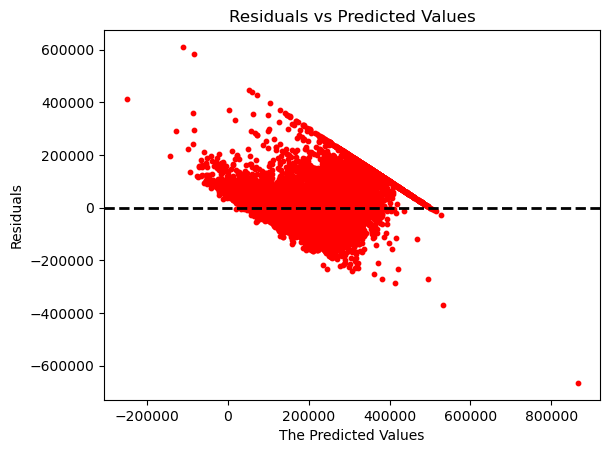

In [17]:
residuals_vs_predicted_values(training_targets, train_predictions)

## Plotting the Residuals Histogram (to check normality)

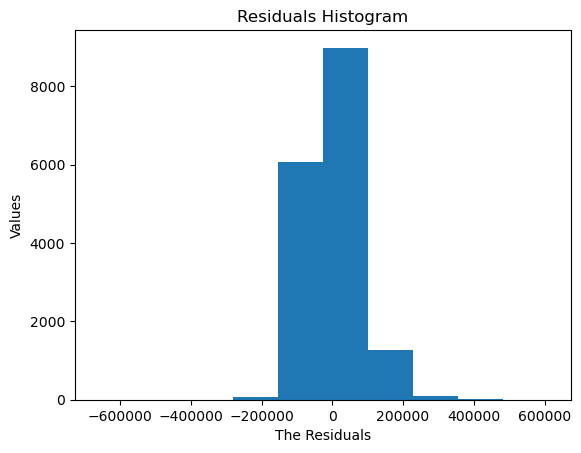

In [18]:
residuals_histogram(training_targets, train_predictions)

## Subset Selection

Select a subset of predictors (Remove predictors that increase complexity without adding much power to the model), using different metrics of evaluation

In [19]:
dataset_X = pd.concat([X, testing_X], ignore_index=True)
dataset_targets = pd.concat([training_targets, testing_targets], ignore_index=True).to_numpy()

In [20]:
len(dataset_X.columns)

15

In [21]:
dataset_X.columns

Index(['longitude', 'latitude', 'housing_median_age', 'bedrooms_per_room',
       'population_per_household', 'rooms_per_household', 'log_total_rooms',
       'log_total_bedrooms', 'log_population', 'log_households',
       'log_median_income', '<1h ocean', 'inland', 'near ocean', 'island'],
      dtype='object')

### 1- Mallow's Cp

In [22]:
mallows_cp_params, mallows_cp_value, mallows_cp_predictors = stepwise_selection(dataset_X, dataset_targets, list(dataset_X.columns), mallows_cp)

Adding the predictor log_median_income resulting in mallows_cp=7340411565.117412
Adding the predictor inland resulting in mallows_cp=5916726742.500988
Adding the predictor housing_median_age resulting in mallows_cp=5749606348.572168
Adding the predictor bedrooms_per_room resulting in mallows_cp=5612014511.449669
Adding the predictor <1h ocean resulting in mallows_cp=5565294147.981692
Adding the predictor log_total_bedrooms resulting in mallows_cp=5522058784.111918
Adding the predictor log_population resulting in mallows_cp=5108462160.675273
Adding the predictor log_households resulting in mallows_cp=5002768074.459522
Adding the predictor population_per_household resulting in mallows_cp=4979971614.136014
Adding the predictor rooms_per_household resulting in mallows_cp=4967210710.827979
Adding the predictor latitude resulting in mallows_cp=4961868853.551138
Adding the predictor longitude resulting in mallows_cp=4789526171.635698
Removing the predictor log_total_bedrooms resulting in mall

In [23]:
len(mallows_cp_predictors)

13

In [24]:
mallows_cp_predictors

['log_median_income',
 'inland',
 'housing_median_age',
 'bedrooms_per_room',
 '<1h ocean',
 'log_population',
 'log_households',
 'population_per_household',
 'rooms_per_household',
 'latitude',
 'longitude',
 'island',
 'near ocean']

### 2- Adjusted R**2

In [25]:
adjusted_r2_params, adjusted_r2_value, adjusted_r2_predictors = stepwise_selection(dataset_X, dataset_targets, list(dataset_X.columns), adjusted_r2, True)

Adding the predictor log_median_income resulting in adjusted_r2=0.44875864437331103
Adding the predictor inland resulting in adjusted_r2=0.5556943328630648
Adding the predictor housing_median_age resulting in adjusted_r2=0.5682648465782705
Adding the predictor bedrooms_per_room resulting in adjusted_r2=0.5786169647927079
Adding the predictor <1h ocean resulting in adjusted_r2=0.5821452462484622
Adding the predictor log_total_bedrooms resulting in adjusted_r2=0.5854115369955875
Adding the predictor log_population resulting in adjusted_r2=0.6164823707543465
Adding the predictor log_households resulting in adjusted_r2=0.6244355414765648
Adding the predictor population_per_household resulting in adjusted_r2=0.6261650081172214
Adding the predictor rooms_per_household resulting in adjusted_r2=0.6271409975938578
Adding the predictor latitude resulting in adjusted_r2=0.6275600157965765
Adding the predictor longitude resulting in adjusted_r2=0.6405135392664564
Removing the predictor log_total_b

In [26]:
len(adjusted_r2_predictors)

13

### 3- AIC

In [27]:
aic_params, aic_value, aic_predictors = stepwise_selection(dataset_X, dataset_targets, list(dataset_X.columns), aic)

Adding the predictor log_median_income resulting in aic=7340411565.117412
Adding the predictor inland resulting in aic=5916726742.500988
Adding the predictor housing_median_age resulting in aic=5749606348.572168
Adding the predictor bedrooms_per_room resulting in aic=5612014511.449669
Adding the predictor <1h ocean resulting in aic=5565294147.981692
Adding the predictor log_total_bedrooms resulting in aic=5522058784.111918
Adding the predictor log_population resulting in aic=5108462160.675273
Adding the predictor log_households resulting in aic=5002768074.459522
Adding the predictor population_per_household resulting in aic=4979971614.136014
Adding the predictor rooms_per_household resulting in aic=4967210710.827979
Adding the predictor latitude resulting in aic=4961868853.551138
Adding the predictor longitude resulting in aic=4789526171.635698
Removing the predictor log_total_bedrooms resulting in aic=4789078329.745486
Adding the predictor island resulting in aic=4785183824.913691
Add

In [28]:
len(aic_predictors)

13

In [29]:
aic_predictors

['log_median_income',
 'inland',
 'housing_median_age',
 'bedrooms_per_room',
 '<1h ocean',
 'log_population',
 'log_households',
 'population_per_household',
 'rooms_per_household',
 'latitude',
 'longitude',
 'island',
 'near ocean']

In [30]:
all_predictors = list(X.columns)
[x for x in all_predictors if x not in aic_predictors]

['log_total_rooms', 'log_total_bedrooms']

### 4- BIC

In [31]:
bic_params, bic_value, bic_predictors = stepwise_selection(dataset_X, dataset_targets, list(dataset_X.columns), bic)

Adding the predictor log_median_income resulting in bic=7343233564.372031
Adding the predictor inland resulting in bic=5921275857.870093
Adding the predictor housing_median_age resulting in bic=5756236962.923106
Adding the predictor bedrooms_per_room resulting in bic=5620643345.981961
Adding the predictor <1h ocean resulting in bic=5575989878.550436
Adding the predictor log_total_bedrooms resulting in bic=5534793333.016464
Adding the predictor log_population resulting in bic=5122205696.369257
Adding the predictor log_households resulting in bic=5018149251.669062
Adding the predictor population_per_household resulting in bic=4997195754.739913
Adding the predictor rooms_per_household resulting in bic=4986298680.482803
Removing the predictor log_total_bedrooms resulting in bic=4985732981.728492
Adding the predictor latitude resulting in bic=4982265626.580507
Adding the predictor longitude resulting in bic=4809321137.302969
Removing the predictor <1h ocean resulting in bic=4807697005.23397

In [32]:
len(bic_predictors)

11

In [33]:
bic_predictors

['log_median_income',
 'inland',
 'housing_median_age',
 'bedrooms_per_room',
 'log_population',
 'log_households',
 'population_per_household',
 'rooms_per_household',
 'latitude',
 'longitude',
 'island']

In [35]:
[x for x in all_predictors if x not in bic_predictors]

['log_total_rooms', 'log_total_bedrooms', '<1h ocean', 'near ocean']